# Gen Z Survival Dashboard 2026
## Steps 3–5: Statistical Analysis, Survival Index & Visualisations

**Prerequisite:** Run `1-2_real_data.ipynb` first to generate `data/processed/master_clean.csv`.

### Methodological choices (all defensible in an interview)
| Method | Why |
|--------|-----|
| Bonferroni-corrected Pearson | n=30 → multiple testing inflates false positives |
| Silhouette score to pick k | More rigorous than elbow alone |
| PCA PC1 for survival index | Data-driven weights instead of arbitrary ones |
| Leave-One-Out CV for regression | Correct for small n |
| `data_reliable` flag preserved | Honest about LinkedIn US-only coverage |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
os.makedirs('visualizations', exist_ok=True)

df = pd.read_csv('data/processed/master_clean.csv')
print(f'Dataset: {df.shape[0]} cities × {df.shape[1]} columns')
print(f'Reliable LinkedIn data: {df["data_reliable"].sum()} cities')
print(f'Regions: {df["region"].value_counts().to_dict()}')

Dataset: 30 cities × 33 columns
Reliable LinkedIn data: 10 cities
Regions: {'Europe': 12, 'North America': 8, 'Asia': 5, 'Oceania': 2, 'Middle East': 2, 'Latin America': 1}


## 3.1 Descriptive Statistics by Theme

In [2]:
ECONOMIC   = ['cost_of_living_index','rent_index','purchasing_power_index',
               'youth_unemployment_rate','inflation_rate','gdp_per_capita_usd']
JOB        = ['total_job_postings','ai_job_postings','ai_pct_of_total',
               'remote_job_ratio','median_salary_usd']
TECH       = ['ai_tool_usage_rate','chatgpt_usage_pct','copilot_usage_pct',
               'remote_hybrid_pct','fully_remote_pct']
# Column names are SO Survey proxy measures (see step 1.6 for definitions)
LIFESTYLE  = ['dev_frustration_pct','job_dissatisfaction_pct',
               'job_satisfaction_pct','hobby_coding_pct']
NUMBEO     = ['quality_of_life_index','healthcare_index','pollution_index']

for label, cols in [('ECONOMIC', ECONOMIC), ('JOB MARKET (LinkedIn)', JOB),
                     ('TECH ADOPTION (SO Survey)', TECH),
                     ('LIFESTYLE PROXIES (SO Survey 2024)', LIFESTYLE),
                     ('QUALITY OF LIFE (Numbeo)', NUMBEO)]:
    print(f'\n--- {label} ---')
    print(df[cols].describe().round(2).to_string())

print('\n⚠️  NOTE: job_dissatisfaction_pct and job_satisfaction_pct are near-perfect'
      ' inverses (same source column). Check their correlation:')
print(df[['job_dissatisfaction_pct','job_satisfaction_pct']].corr().round(3).to_string())



--- ECONOMIC ---
       cost_of_living_index  rent_index  purchasing_power_index  youth_unemployment_rate  inflation_rate  gdp_per_capita_usd
count                 30.00       30.00                   30.00                    30.00           30.00               30.00
mean                  72.77       48.35                   93.62                    11.54            2.80            58010.14
std                   19.62       21.56                   22.39                     5.34            0.90            26828.71
min                   25.70        7.90                   38.10                     3.90            1.06             2694.74
25%                   66.40       33.60                   82.78                     7.35            2.34            47145.69
50%                   73.45       46.35                   96.15                     9.48            2.80            55222.04
75%                   81.20       61.52                  103.42                    14.44            3.14   

## 3.2 Correlation Analysis (Bonferroni-corrected)

With n=30, running uncorrected pairwise correlations would produce many false positives.
We apply Bonferroni correction: α / number_of_tests.

Column availability check:
  cost_of_living_index: 30/30 non-null
  gdp_per_capita_usd: 30/30 non-null
  youth_unemployment_rate: 30/30 non-null
  ai_job_postings: 30/30 non-null
  remote_job_ratio: 30/30 non-null
  ai_tool_usage_rate: 30/30 non-null
  chatgpt_usage_pct: 30/30 non-null
  remote_hybrid_pct: 30/30 non-null
  dev_frustration_pct: 30/30 non-null
  hobby_coding_pct: 30/30 non-null
  job_satisfaction_pct: 30/30 non-null
  quality_of_life_index: 30/30 non-null

Vars kept: 12/12
Dropped: set()

Significant correlations (|r| > 0.4, Bonferroni α=0.00076):
          Variable 1            Variable 2     r       p  n
cost_of_living_index    gdp_per_capita_usd 0.840 0.00000 30
   remote_hybrid_pct  job_satisfaction_pct 0.686 0.00003 30
cost_of_living_index      hobby_coding_pct 0.637 0.00016 30
    hobby_coding_pct quality_of_life_index 0.585 0.00069 30


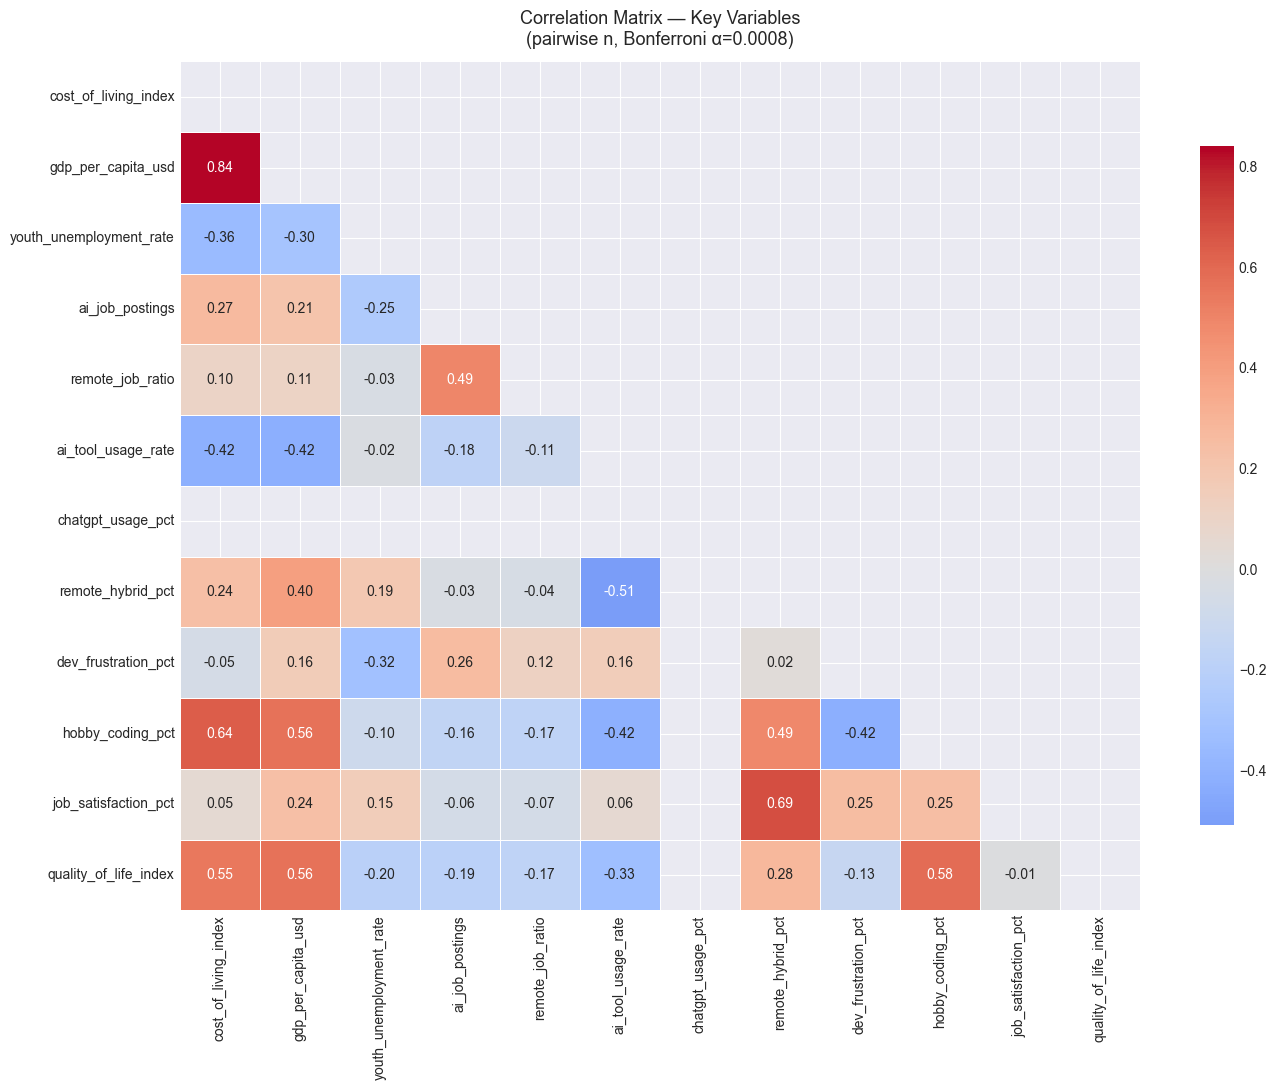

✅ Saved


In [3]:
# Drop job_dissatisfaction_pct from KEY_VARS since job_satisfaction_pct captures
# the same signal (they're near-perfect inverses). Including both inflates the
# correlation heatmap with an artificial -1.0 entry.
KEY_VARS = [
    'cost_of_living_index', 'gdp_per_capita_usd', 'youth_unemployment_rate',
    'ai_job_postings', 'remote_job_ratio', 'ai_tool_usage_rate',
    'chatgpt_usage_pct', 'remote_hybrid_pct', 'dev_frustration_pct',
    'hobby_coding_pct', 'job_satisfaction_pct', 'quality_of_life_index',
]

# STEP 1: Diagnose the problem first
print('Column availability check:')
for col in KEY_VARS:
    if col not in df.columns:
        print(f'  MISSING FROM DATAFRAME: {col}')
    else:
        n_valid = df[col].notna().sum()
        print(f'  {col}: {n_valid}/30 non-null')

# STEP 2: Only keep vars with enough data (at least 20 non-null rows)
KEY_VARS_AVAILABLE = [
    col for col in KEY_VARS
    if col in df.columns and df[col].notna().sum() >= 20
]
print(f'\nVars kept: {len(KEY_VARS_AVAILABLE)}/{len(KEY_VARS)}')
print(f'Dropped: {set(KEY_VARS) - set(KEY_VARS_AVAILABLE)}')

# STEP 3: Pairwise correlations (each pair uses rows where both are non-null)
df_kv = df[KEY_VARS_AVAILABLE]

n_tests  = len(KEY_VARS_AVAILABLE) * (len(KEY_VARS_AVAILABLE) - 1) // 2
alpha_bf = 0.05 / n_tests

sig_pairs = []
for i, v1 in enumerate(KEY_VARS_AVAILABLE):
    for j, v2 in enumerate(KEY_VARS_AVAILABLE):
        if j <= i: continue
        pair = df[[v1, v2]].dropna()
        n_pair = len(pair)
        if n_pair < 5:
            print(f'  Skipping {v1} vs {v2}: only {n_pair} valid rows')
            continue
        r, p = stats.pearsonr(pair[v1], pair[v2])
        if abs(r) > 0.4 and p < alpha_bf:
            sig_pairs.append({
                'Variable 1': v1, 'Variable 2': v2,
                'r': round(r, 3), 'p': round(p, 5), 'n': n_pair
            })

df_sig = pd.DataFrame(sig_pairs).sort_values('r', ascending=False) if sig_pairs else pd.DataFrame()
print(f'\nSignificant correlations (|r| > 0.4, Bonferroni α={alpha_bf:.5f}):')
print(df_sig.to_string(index=False) if not df_sig.empty else 'None at this threshold.')

# STEP 4: Heatmap
corr = df_kv.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title(f'Correlation Matrix — Key Variables\n'
             f'(pairwise n, Bonferroni α={alpha_bf:.4f})', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('visualizations/01_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')


## 3.3 Cost of Living vs Burnout & Side Hustle (Real Trends Data)

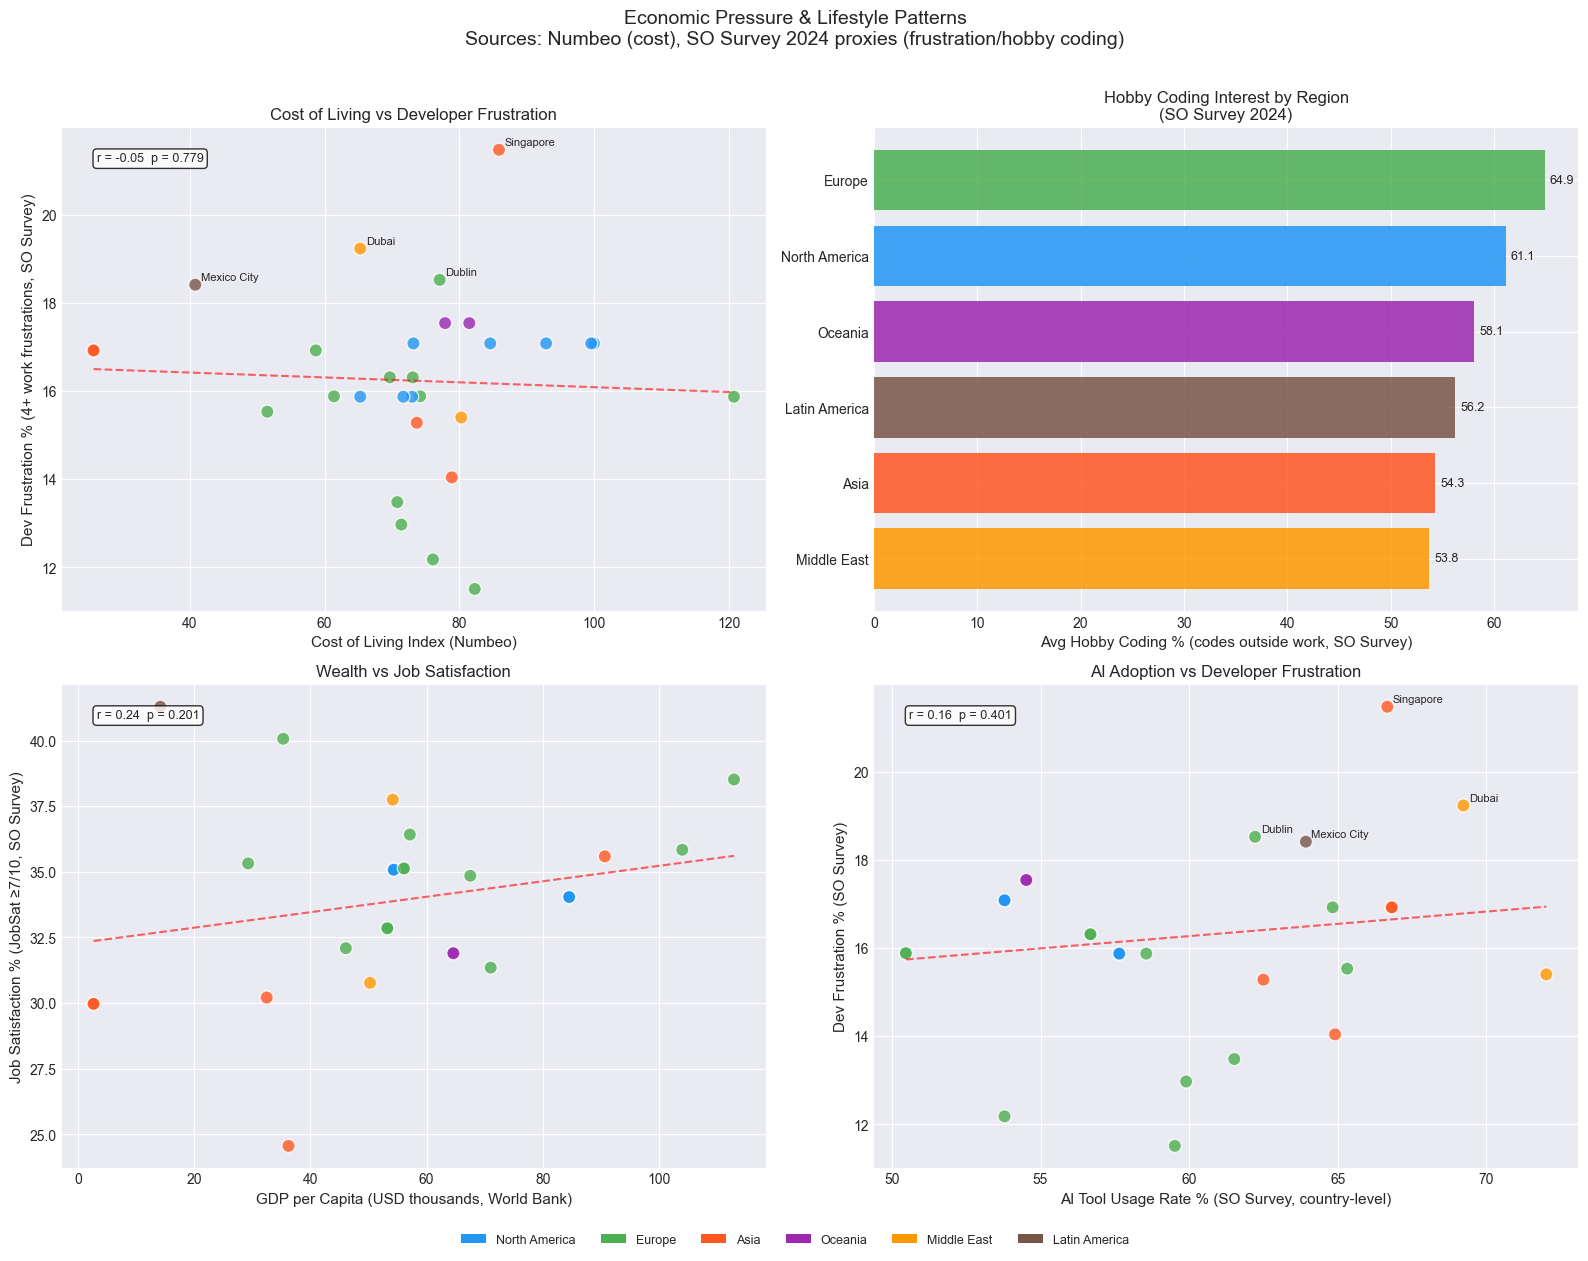

✅ Saved


In [4]:
REGION_COLORS = {
    'North America':'#2196F3', 'Europe':'#4CAF50', 'Asia':'#FF5722',
    'Oceania':'#9C27B0', 'Middle East':'#FF9800', 'Latin America':'#795548'
}

def annotate_top(ax, df, x_col, y_col, n=4):
    for _, row in df.nlargest(n, y_col).iterrows():
        ax.annotate(row['city'], (row[x_col], row[y_col]),
                    fontsize=8, xytext=(4,3), textcoords='offset points')

def add_trendline(ax, x, y):
    mask = x.notna() & y.notna()
    if mask.sum() < 5: return
    z = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'r--', alpha=0.6, linewidth=1.5)
    r, p = stats.pearsonr(x[mask], y[mask])
    ax.text(0.05, 0.93, f'r = {r:.2f}  p = {p:.3f}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Economic Pressure & Lifestyle Patterns\n'
             'Sources: Numbeo (cost), SO Survey 2024 proxies (frustration/hobby coding)',
             fontsize=14, y=1.01)

# 1: Cost of Living vs Developer Frustration
ax = axes[0, 0]
colors = [REGION_COLORS.get(r, '#607D8B') for r in df['region']]
ax.scatter(df['cost_of_living_index'], df['dev_frustration_pct'],
           c=colors, s=90, alpha=0.8, edgecolors='white')
add_trendline(ax, df['cost_of_living_index'], df['dev_frustration_pct'])
annotate_top(ax, df, 'cost_of_living_index', 'dev_frustration_pct')
ax.set_xlabel('Cost of Living Index (Numbeo)', fontsize=11)
ax.set_ylabel('Dev Frustration % (4+ work frustrations, SO Survey)', fontsize=11)
ax.set_title('Cost of Living vs Developer Frustration', fontsize=12)

# 2: Hobby Coding by Region
ax = axes[0, 1]
region_sh = df.groupby('region')['hobby_coding_pct'].mean().sort_values()
bars = ax.barh(region_sh.index, region_sh.values,
               color=[REGION_COLORS.get(r,'#607D8B') for r in region_sh.index], alpha=0.85)
for bar, val in zip(bars, region_sh.values):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Avg Hobby Coding % (codes outside work, SO Survey)', fontsize=11)
ax.set_title('Hobby Coding Interest by Region\n(SO Survey 2024)', fontsize=12)

# 3: GDP per capita vs Job Satisfaction
ax = axes[1, 0]
ax.scatter(df['gdp_per_capita_usd']/1000, df['job_satisfaction_pct'],
           c=colors, s=90, alpha=0.8, edgecolors='white')
add_trendline(ax, df['gdp_per_capita_usd']/1000, df['job_satisfaction_pct'])
annotate_top(ax, df, 'gdp_per_capita_usd', 'job_satisfaction_pct')
ax.set_xlabel('GDP per Capita (USD thousands, World Bank)', fontsize=11)
ax.set_ylabel('Job Satisfaction % (JobSat ≥7/10, SO Survey)', fontsize=11)
ax.set_title('Wealth vs Job Satisfaction', fontsize=12)

# 4: AI Adoption vs Developer Frustration
ax = axes[1, 1]
ax.scatter(df['ai_tool_usage_rate'], df['dev_frustration_pct'],
           c=colors, s=90, alpha=0.8, edgecolors='white')
add_trendline(ax, df['ai_tool_usage_rate'], df['dev_frustration_pct'])
annotate_top(ax, df, 'ai_tool_usage_rate', 'dev_frustration_pct')
ax.set_xlabel('AI Tool Usage Rate % (SO Survey, country-level)', fontsize=11)
ax.set_ylabel('Dev Frustration % (SO Survey)', fontsize=11)
ax.set_title('AI Adoption vs Developer Frustration', fontsize=12)

# Region legend
legend_elements = [mpatches.Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('visualizations/02_economic_lifestyle.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')


## 3.4 AI Opportunity Analysis (LinkedIn + SO Survey)

Reliable cities for LinkedIn analysis: 10
         city  ai_job_postings  ai_pct_of_total  remote_job_ratio
     New York             46.0             1.67              5.62
San Francisco             31.0             3.21              8.89
      Seattle             19.0             2.32              7.57
       Boston             18.0             1.50              9.58
       Austin             16.0             1.48              7.11
    Melbourne              1.0             0.76              4.58
       London              0.0             0.00              8.33
       Berlin              0.0             0.00              1.92
    Vancouver              0.0             0.00              4.35
       Dublin              0.0             0.00              5.62


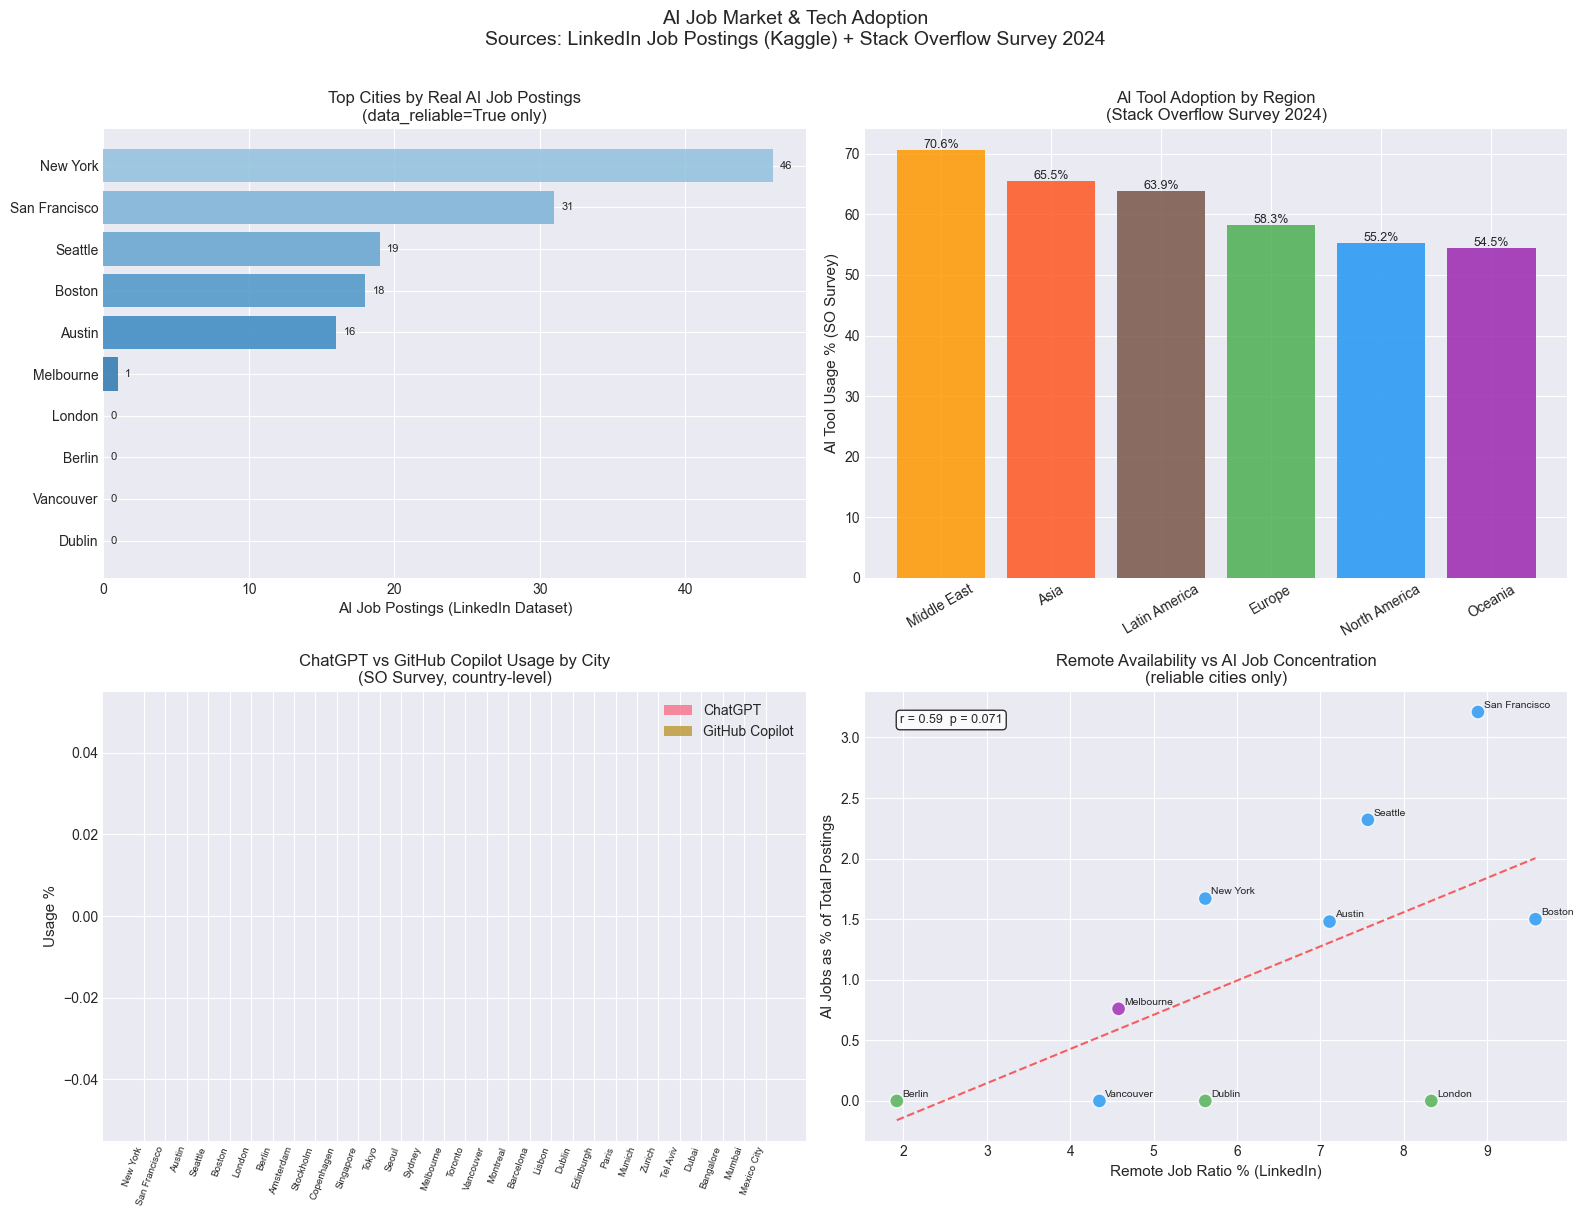

✅ Saved


In [5]:
df_reliable = df[df['data_reliable'].astype(float) == 1.0].copy()
print(f'Reliable cities for LinkedIn analysis: {len(df_reliable)}')
print(df_reliable[['city','ai_job_postings','ai_pct_of_total','remote_job_ratio']]
      .sort_values('ai_job_postings', ascending=False).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AI Job Market & Tech Adoption\n'
             'Sources: LinkedIn Job Postings (Kaggle) + Stack Overflow Survey 2024',
             fontsize=14, y=1.01)

# 1: Top cities by real AI job postings
ax = axes[0, 0]
top_ai = df_reliable.nlargest(12, 'ai_job_postings')[['city','ai_job_postings']]
bars = ax.barh(top_ai['city'], top_ai['ai_job_postings'],
               color=sns.color_palette('Blues_d', len(top_ai)), alpha=0.9)
for bar, val in zip(bars, top_ai['ai_job_postings']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, str(int(val)), va='center', fontsize=8)
ax.set_xlabel('AI Job Postings (LinkedIn Dataset)', fontsize=11)
ax.set_title('Top Cities by Real AI Job Postings\n(data_reliable=True only)', fontsize=12)
ax.invert_yaxis()

# 2: AI tool usage by region (SO Survey)
ax = axes[0, 1]
region_ai = df.groupby('region')['ai_tool_usage_rate'].mean().sort_values(ascending=False)
ax.bar(region_ai.index, region_ai.values,
       color=[REGION_COLORS.get(r,'#607D8B') for r in region_ai.index], alpha=0.85)
ax.set_ylabel('AI Tool Usage % (SO Survey)', fontsize=11)
ax.set_title('AI Tool Adoption by Region\n(Stack Overflow Survey 2024)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
for i, val in enumerate(region_ai.values):
    ax.text(i, val+0.3, f'{val:.1f}%', ha='center', fontsize=9)

# 3: ChatGPT vs Copilot usage
ax = axes[1, 0]
x = np.arange(len(df))
width = 0.4
df_sorted = df.sort_values('chatgpt_usage_pct', ascending=False)
ax.bar(x - width/2, df_sorted['chatgpt_usage_pct'], width, label='ChatGPT', alpha=0.8)
ax.bar(x + width/2, df_sorted['copilot_usage_pct'], width, label='GitHub Copilot', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['city'], rotation=70, ha='right', fontsize=7)
ax.set_ylabel('Usage %', fontsize=11)
ax.set_title('ChatGPT vs GitHub Copilot Usage by City\n(SO Survey, country-level)', fontsize=12)
ax.legend()

# 4: Remote job ratio vs AI % of total (reliable cities only)
ax = axes[1, 1]
colors_rel = [REGION_COLORS.get(r,'#607D8B') for r in df_reliable['region']]
sc = ax.scatter(df_reliable['remote_job_ratio'], df_reliable['ai_pct_of_total'],
                c=colors_rel, s=100, alpha=0.8, edgecolors='white')
for _, row in df_reliable.iterrows():
    ax.annotate(row['city'], (row['remote_job_ratio'], row['ai_pct_of_total']),
                fontsize=7.5, xytext=(4,3), textcoords='offset points')
add_trendline(ax, df_reliable['remote_job_ratio'], df_reliable['ai_pct_of_total'])
ax.set_xlabel('Remote Job Ratio % (LinkedIn)', fontsize=11)
ax.set_ylabel('AI Jobs as % of Total Postings', fontsize=11)
ax.set_title('Remote Availability vs AI Job Concentration\n(reliable cities only)', fontsize=12)

plt.tight_layout()
plt.savefig('visualizations/03_ai_opportunity.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')

## 3.5 Lifestyle & Wellness Trends

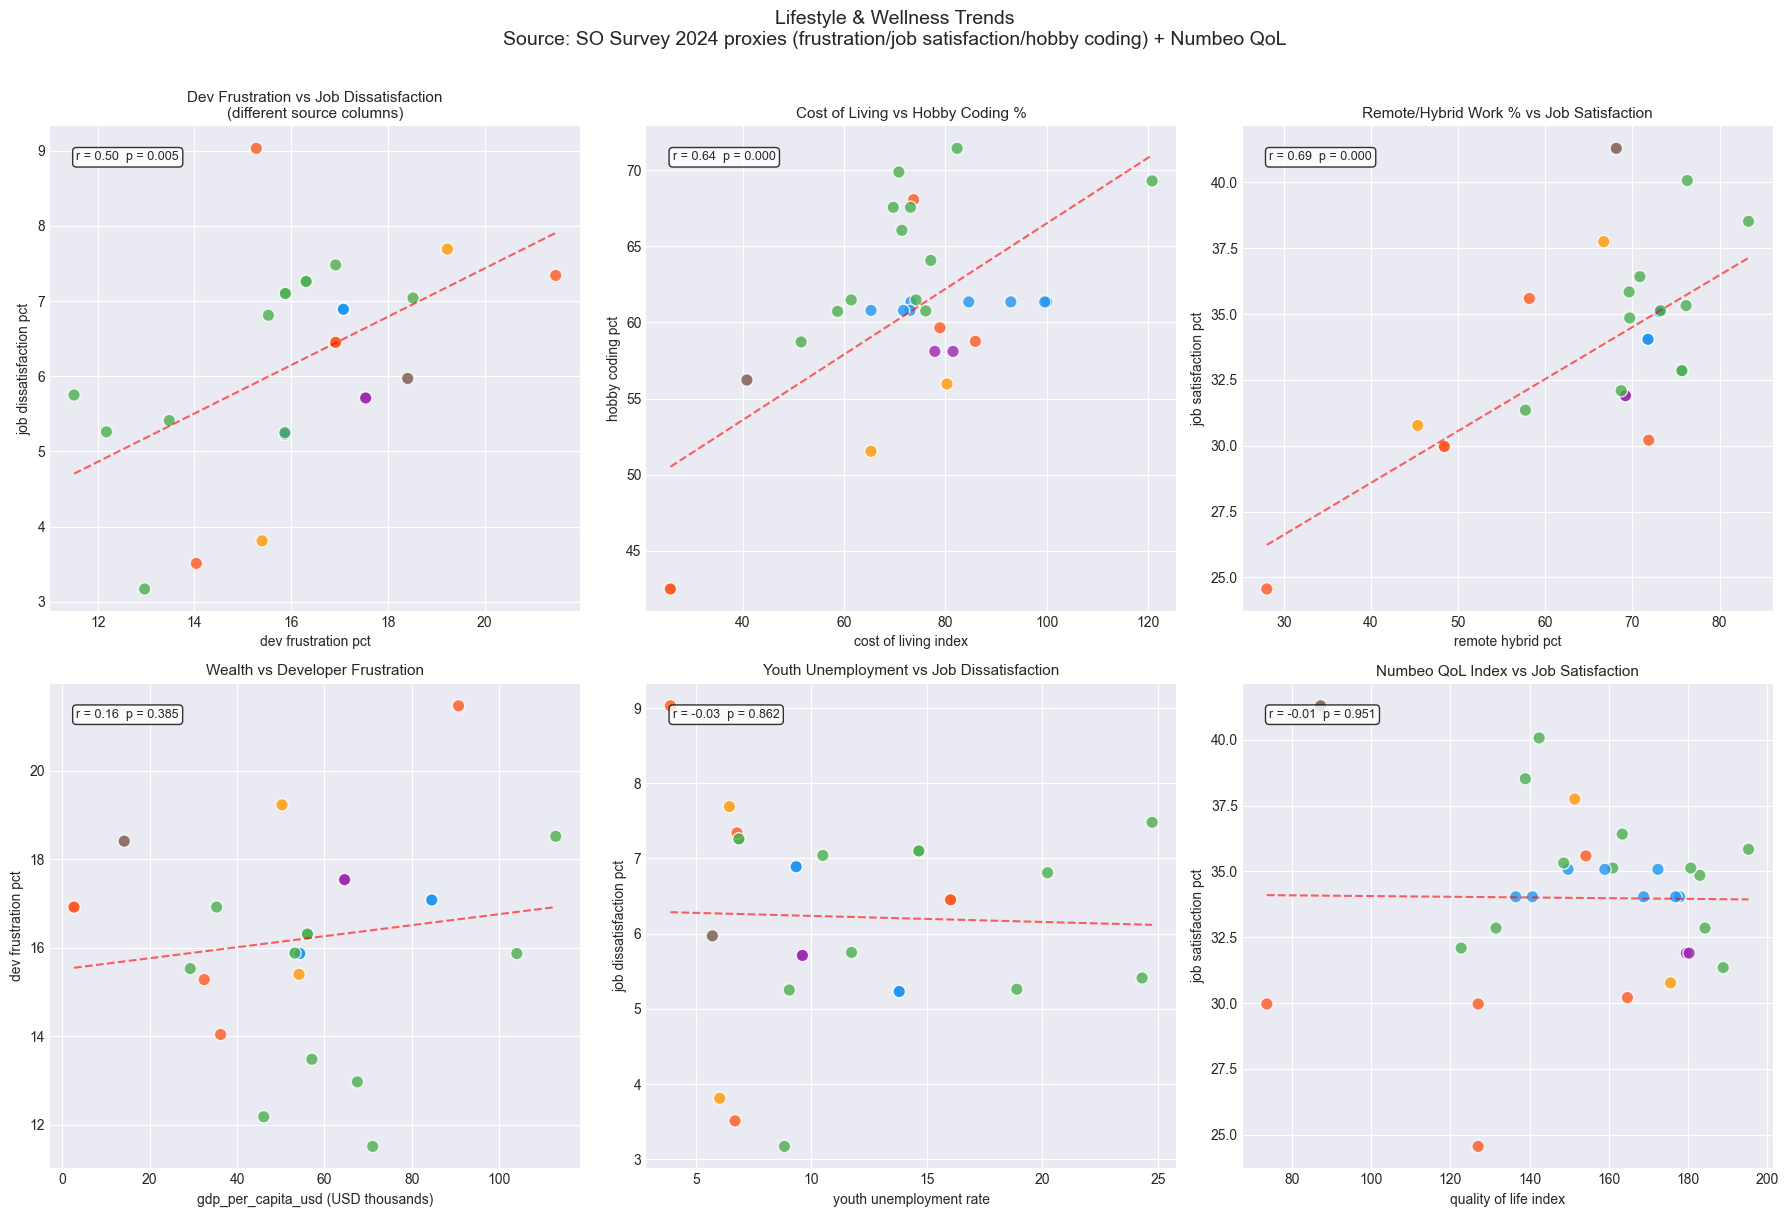

✅ Saved


In [6]:
# NOTE: job_dissatisfaction_pct and job_satisfaction_pct are near-perfect inverses
# from the same JobSat column. Plotting both together would be misleading — the
# first panel (frustration vs dissatisfaction) is retained because these come from
# different source columns (Frustration vs JobSat) and are not mechanically correlated.

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lifestyle & Wellness Trends\n'
             'Source: SO Survey 2024 proxies (frustration/job satisfaction/hobby coding) + Numbeo QoL',
             fontsize=14, y=1.01)

panels = [
    (axes[0,0], 'dev_frustration_pct', 'job_dissatisfaction_pct',
     'Dev Frustration vs Job Dissatisfaction\n(different source columns)'),
    (axes[0,1], 'cost_of_living_index', 'hobby_coding_pct',
     'Cost of Living vs Hobby Coding %'),
    (axes[0,2], 'remote_hybrid_pct', 'job_satisfaction_pct',
     'Remote/Hybrid Work % vs Job Satisfaction'),
    (axes[1,0], 'gdp_per_capita_usd', 'dev_frustration_pct',
     'Wealth vs Developer Frustration'),
    (axes[1,1], 'youth_unemployment_rate', 'job_dissatisfaction_pct',
     'Youth Unemployment vs Job Dissatisfaction'),
    (axes[1,2], 'quality_of_life_index', 'job_satisfaction_pct',
     'Numbeo QoL Index vs Job Satisfaction'),
]

for ax, xcol, ycol, title in panels:
    colors = [REGION_COLORS.get(r,'#607D8B') for r in df['region']]
    xvals = df[xcol] / 1000 if xcol == 'gdp_per_capita_usd' else df[xcol]
    xlabel = f'{xcol} (USD thousands)' if xcol == 'gdp_per_capita_usd' else xcol.replace('_',' ')
    ax.scatter(xvals, df[ycol], c=colors, s=80, alpha=0.8, edgecolors='white')
    add_trendline(ax, xvals, df[ycol])
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ycol.replace('_',' '), fontsize=10)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/04_lifestyle_wellness.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')


## 3.6 K-Means City Clustering

We use silhouette score (not just elbow) to select k, and visualise in PCA 2D space.
With n=30, clusters are interpretive, not statistically precise.

Cities for clustering: 30


Silhouette-optimal k: 7 (score: 0.282)


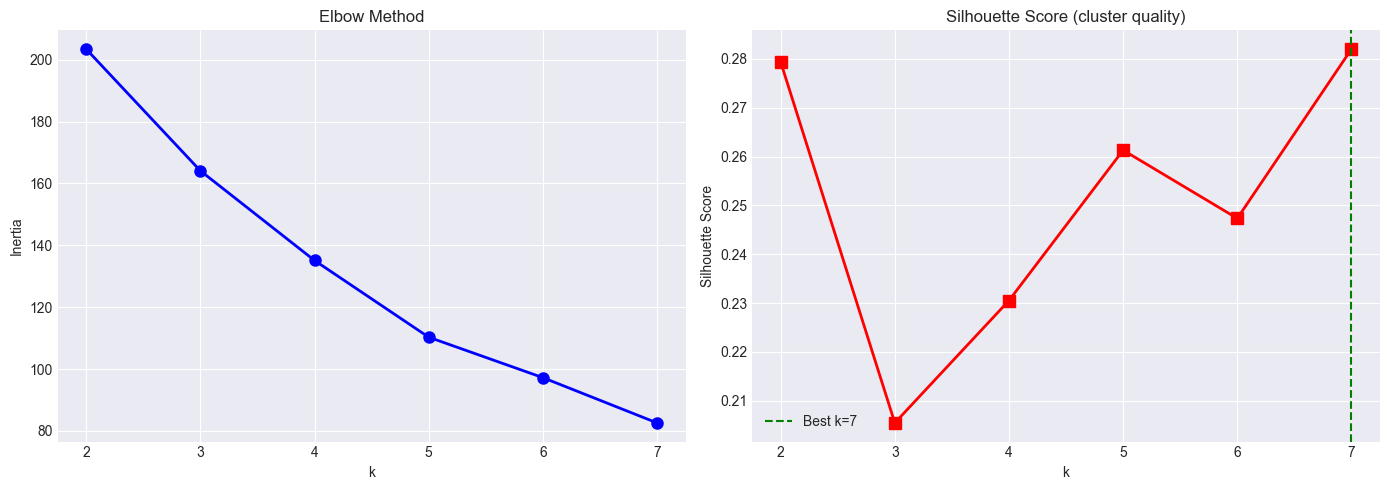

Variance explained by 2 PCs: 58.9%

Cluster Profiles:
         cost_of_living_index  gdp_per_capita_usd  youth_unemployment_rate  ai_job_postings  remote_job_ratio  ai_tool_usage_rate  chatgpt_usage_pct  hobby_coding_pct  dev_frustration_pct  quality_of_life_index
cluster                                                                                                                                                                                                           
0                       64.28            41959.90                    22.04             0.00              5.62               61.36                0.0             62.52                14.53                 144.28
1                       82.85            73074.66                    11.12            20.88              7.72               54.34                0.0             61.23                16.63                 155.12
2                       30.73             6525.09                    12.59             8.50           

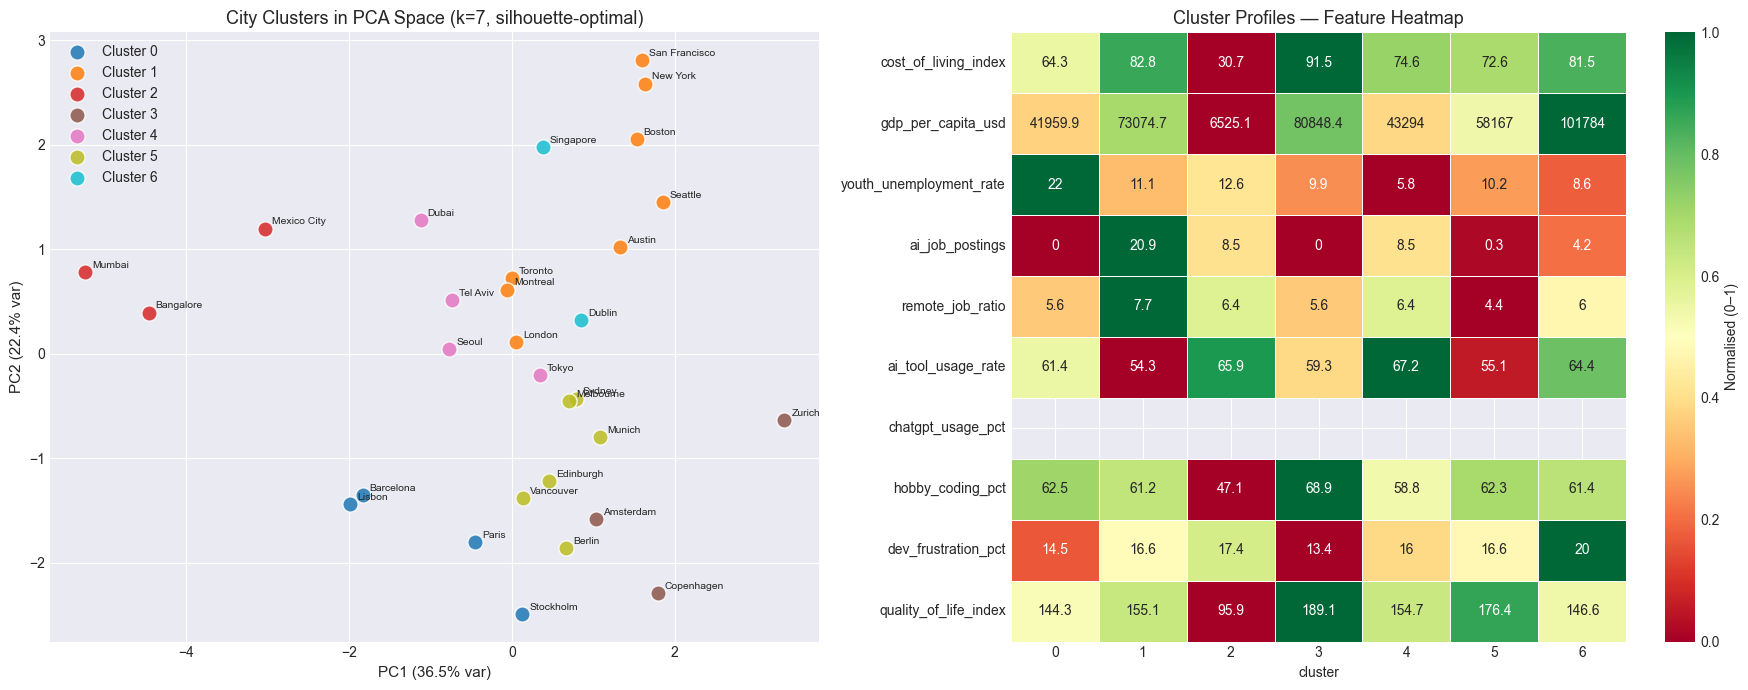

✅ Clustering saved


In [7]:
CLUSTER_FEATURES = [
    'cost_of_living_index', 'gdp_per_capita_usd', 'youth_unemployment_rate',
    'ai_job_postings', 'remote_job_ratio', 'ai_tool_usage_rate',
    'chatgpt_usage_pct', 'hobby_coding_pct', 'dev_frustration_pct', 'quality_of_life_index',
]

df_cl = df[['city','country','region'] + CLUSTER_FEATURES].dropna().copy()
print(f'Cities for clustering: {len(df_cl)}')

X = df_cl[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_range = range(2, min(8, len(df_cl)//3 + 1))
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Silhouette-optimal k: {best_k} (score: {max(sil_scores):.3f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-', lw=2, ms=8)
axes[0].set(xlabel='k', ylabel='Inertia', title='Elbow Method')
axes[1].plot(list(K_range), sil_scores, 'rs-', lw=2, ms=8)
axes[1].axvline(best_k, color='green', ls='--', label=f'Best k={best_k}')
axes[1].set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Score (cluster quality)')
axes[1].legend()
plt.tight_layout()
plt.savefig('visualizations/05a_cluster_selection.png', dpi=300, bbox_inches='tight')
plt.show()

# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl['cluster'] = km_final.fit_predict(X_scaled)

# PCA 2D for visualisation
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_scaled)
df_cl['pca_1'] = coords[:, 0]
df_cl['pca_2'] = coords[:, 1]
print(f'Variance explained by 2 PCs: {pca_2d.explained_variance_ratio_.sum():.1%}')

# Cluster profiles
print('\nCluster Profiles:')
print(df_cl.groupby('cluster')[CLUSTER_FEATURES].mean().round(2).to_string())
print('\nCities per cluster:')
for c in sorted(df_cl['cluster'].unique()):
    print(f'  Cluster {c}: {df_cl[df_cl["cluster"]==c]["city"].tolist()}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cluster_cmap = plt.cm.tab10(np.linspace(0, 1, best_k))

ax1 = axes[0]
for c in range(best_k):
    mask = df_cl['cluster'] == c
    ax1.scatter(df_cl[mask]['pca_1'], df_cl[mask]['pca_2'],
                s=120, alpha=0.85, color=cluster_cmap[c], label=f'Cluster {c}',
                edgecolors='white')
    for _, row in df_cl[mask].iterrows():
        ax1.annotate(row['city'], (row['pca_1'], row['pca_2']),
                     fontsize=7.5, xytext=(5,3), textcoords='offset points')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)', fontsize=11)
ax1.set_title(f'City Clusters in PCA Space (k={best_k}, silhouette-optimal)', fontsize=13)
ax1.legend()

ax2 = axes[1]
profile = df_cl.groupby('cluster')[CLUSTER_FEATURES].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm.T, annot=profile.T.round(1), fmt='g',
            cmap='RdYlGn', ax=ax2, linewidths=0.5, cbar_kws={'label': 'Normalised (0–1)'})
ax2.set_title('Cluster Profiles — Feature Heatmap', fontsize=13)

plt.tight_layout()
plt.savefig('visualizations/05_city_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

df_cl.to_csv('data/processed/cities_clustered.csv', index=False)
print('✅ Clustering saved')

## 4.1 Gen Z Survival Index — PCA PC1 (Data-Driven Weights)

**Why PCA instead of manual weights?**
The first principal component is the linear combination of variables that captures the most
variance across cities. The loadings become the feature weights — derived from data, not gut feel.

**Interview answer:** *"Weights were derived from the first principal component of a PCA over real data.
The loading vector tells you exactly how much each variable contributes and in which direction."*

In [8]:
# Which direction is 'good for Gen Z'? flip=True means higher raw value = worse
# job_dissatisfaction_pct is EXCLUDED: it is a near-perfect inverse of
# job_satisfaction_pct (same JobSat source column). Including both would double-weight
# job satisfaction in the PCA and inflate its contribution.
SURVIVAL_FEATURES = {
    'cost_of_living_index':     True,   # expensive = bad
    'rent_index':               True,   # high rent = bad
    'youth_unemployment_rate':  True,   # unemployment = bad
    'inflation_rate':           True,   # inflation = bad
    'gdp_per_capita_usd':       False,  # high GDP = good
    'ai_job_postings':          False,  # more AI jobs = good
    'ai_pct_of_total':          False,  # AI concentration = good
    'remote_hybrid_pct':        False,  # more remote/hybrid = good
    'ai_tool_usage_rate':       False,  # high adoption = good
    'chatgpt_usage_pct':        False,  # AI fluency = good
    'job_satisfaction_pct':     False,  # higher job satisfaction = good
    'dev_frustration_pct':      True,   # high frustration = bad
    'quality_of_life_index':    False,  # high QoL = good
    'pollution_index':          True,   # high pollution = bad
}

feat_names = list(SURVIVAL_FEATURES.keys())
df_surv = df[['city','country','region'] + feat_names].dropna().copy()
print(f'Cities with complete survival data: {len(df_surv)}')

X_surv = df_surv[feat_names].copy()
for feat, flip in SURVIVAL_FEATURES.items():
    if flip:
        X_surv[feat] = -X_surv[feat]

sc = StandardScaler()
X_surv_scaled = sc.fit_transform(X_surv)

pca_surv = PCA(n_components=3, random_state=42)
pca_surv.fit(X_surv_scaled)

print(f'PC1 variance explained: {pca_surv.explained_variance_ratio_[0]:.1%}')
print(f'Cumulative (PC1+2+3):   {pca_surv.explained_variance_ratio_.cumsum()[2]:.1%}')

loadings = pd.Series(pca_surv.components_[0], index=feat_names)
print('\nPC1 Loadings (feature weights in survival index):')
print(loadings.sort_values(ascending=False).round(4).to_string())

scores_raw    = pca_surv.transform(X_surv_scaled)[:, 0]
scores_scaled = ((scores_raw - scores_raw.min()) /
                 (scores_raw.max() - scores_raw.min()) * 100).round(2)

df_surv['gen_z_survival_index'] = scores_scaled
df_ranked = (df_surv[['city','country','region','gen_z_survival_index'] + feat_names]
             .sort_values('gen_z_survival_index', ascending=False)
             .reset_index(drop=True))

print('\n' + '='*55)
print('GEN Z SURVIVAL INDEX — FULL RANKING')
print('(PCA PC1, real data, higher = better for Gen Z)')
print('='*55)
print(df_ranked[['city','country','region','gen_z_survival_index']].to_string(index=False))

df_ranked.to_csv('data/processed/survival_index_rankings.csv', index=False)


Cities with complete survival data: 30
PC1 variance explained: 35.1%
Cumulative (PC1+2+3):   70.6%

PC1 Loadings (feature weights in survival index):
gdp_per_capita_usd         0.4313
pollution_index            0.3668
quality_of_life_index      0.3461
inflation_rate             0.3182
remote_hybrid_pct          0.2257
youth_unemployment_rate    0.1411
job_satisfaction_pct       0.0887
ai_job_postings            0.0849
ai_pct_of_total            0.0269
chatgpt_usage_pct         -0.0000
dev_frustration_pct       -0.0083
ai_tool_usage_rate        -0.2557
rent_index                -0.3589
cost_of_living_index      -0.4213

GEN Z SURVIVAL INDEX — FULL RANKING
(PCA PC1, real data, higher = better for Gen Z)
         city     country        region  gen_z_survival_index
       Zurich Switzerland        Europe                100.00
      Seattle         USA North America                 84.00
     New York         USA North America                 82.63
San Francisco         USA North America  

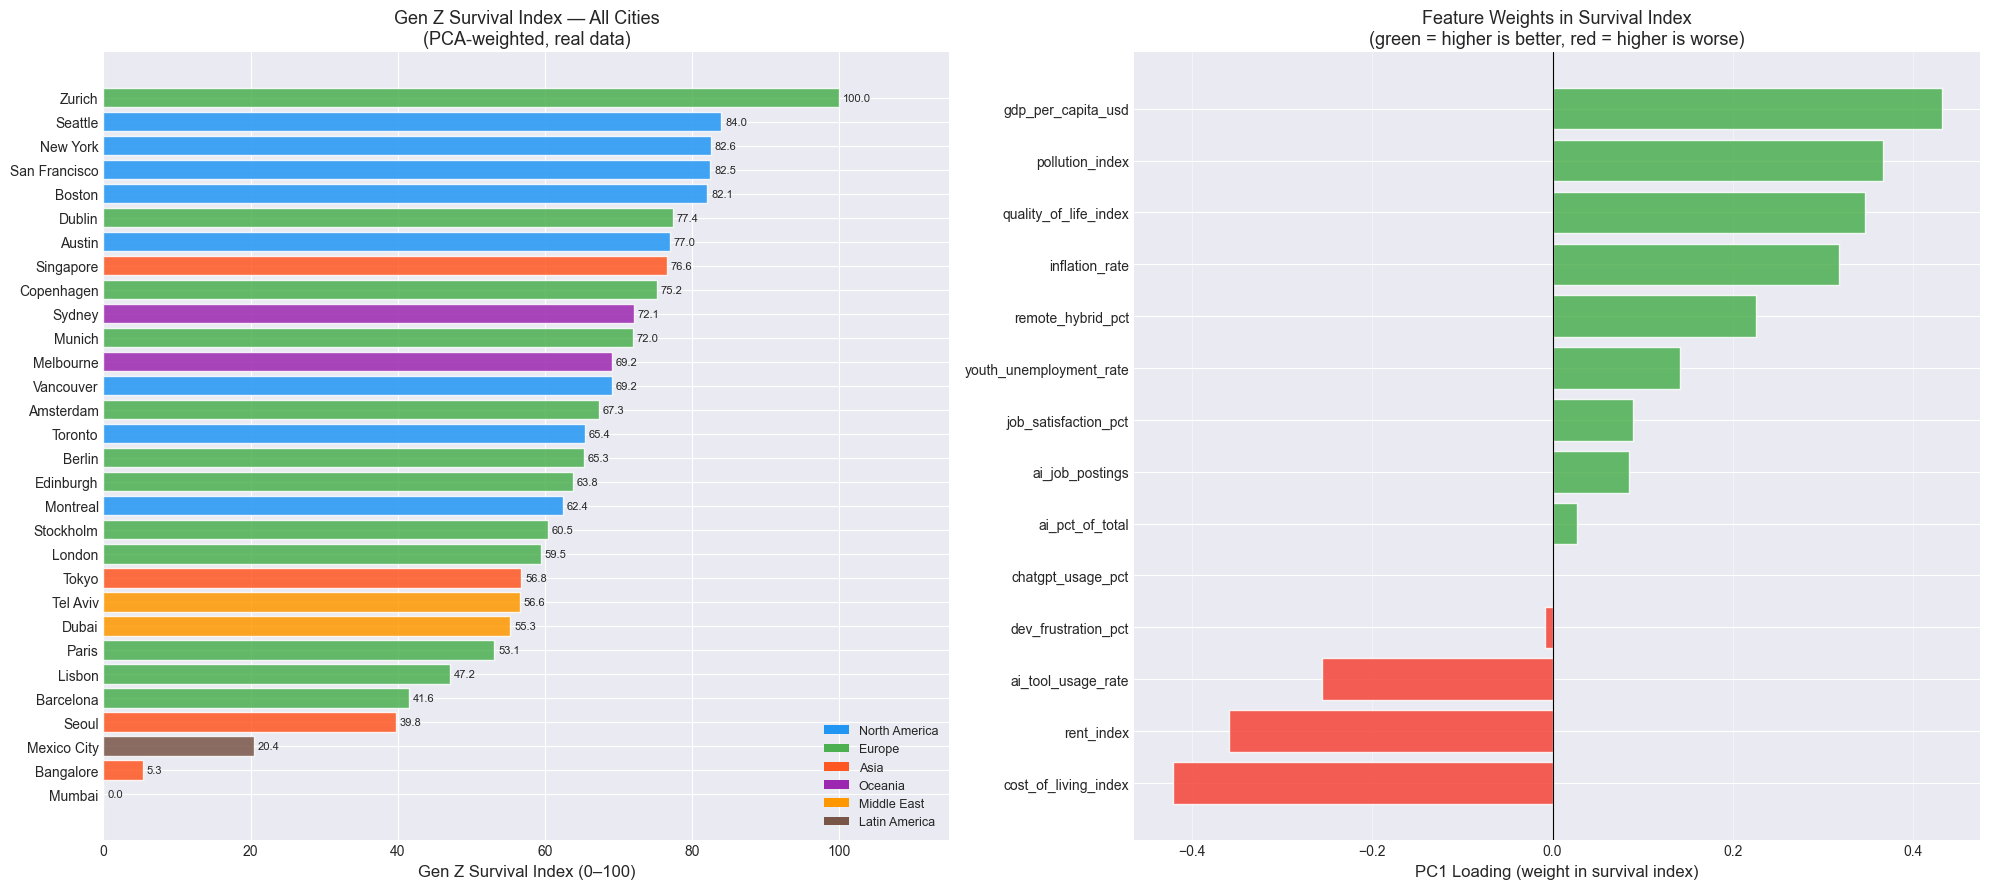

✅ Saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Left: Ranked bar chart
ax1 = axes[0]
bar_colors = [REGION_COLORS.get(r,'#607D8B') for r in df_ranked['region']]
bars = ax1.barh(df_ranked['city'], df_ranked['gen_z_survival_index'],
                color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, df_ranked['gen_z_survival_index']):
    ax1.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8)
legend_els = [mpatches.Patch(facecolor=c, label=r) for r,c in REGION_COLORS.items()]
ax1.legend(handles=legend_els, fontsize=9, loc='lower right')
ax1.set_xlabel('Gen Z Survival Index (0–100)', fontsize=12)
ax1.set_title('Gen Z Survival Index — All Cities\n'
              '(PCA-weighted, real data)', fontsize=13)
ax1.invert_yaxis()
ax1.set_xlim(0, 115)

# Right: PCA loadings
ax2 = axes[1]
loadings_s = loadings.sort_values()
bar_colors2 = ['#4CAF50' if v > 0 else '#F44336' for v in loadings_s]
ax2.barh(loadings_s.index, loadings_s.values, color=bar_colors2, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('PC1 Loading (weight in survival index)', fontsize=12)
ax2.set_title('Feature Weights in Survival Index\n'
              '(green = higher is better, red = higher is worse)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('visualizations/06_survival_index.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')

## 4.2 Regression: What Predicts the Survival Index?

With n=30, we use max 4 predictors (rule of thumb: ~10 obs per predictor).
Leave-One-Out CV is the correct validation strategy for this sample size.

**Important:** predictors must NOT be features that entered the PCA survival index,
or the regression becomes circular (of course inputs predict their own weighted sum).
We instead use variables available in the dataset that were **not** in `SURVIVAL_FEATURES`:
- `median_salary_usd` — actual reported salaries (LinkedIn)
- `purchasing_power_index` — Numbeo local purchasing power (not just cost)
- `healthcare_index` — Numbeo healthcare quality
- `fully_remote_pct` — share fully remote workers (SO Survey)

This tests whether omitted practical factors predict the index independently.


In [10]:
# Predictors chosen from variables NOT in SURVIVAL_FEATURES (avoids circular reasoning)
PREDICTORS = [
    'median_salary_usd',       # actual salary (LinkedIn) — not in PCA
    'purchasing_power_index',  # Numbeo local purchasing power — not in PCA
    'healthcare_index',        # Numbeo healthcare quality — not in PCA
    'fully_remote_pct',        # % fully remote (SO Survey) — not in PCA
]

df_reg = df_surv[PREDICTORS + ['gen_z_survival_index']].dropna()
X_reg  = df_reg[PREDICTORS].values
y_reg  = df_reg['gen_z_survival_index'].values

loo        = LeaveOneOut()
y_pred_loo = np.zeros(len(y_reg))

for train_idx, test_idx in loo.split(X_reg):
    sc_loo  = StandardScaler()
    X_tr_s  = sc_loo.fit_transform(X_reg[train_idx])
    X_te_s  = sc_loo.transform(X_reg[test_idx])
    reg     = LinearRegression().fit(X_tr_s, y_reg[train_idx])
    y_pred_loo[test_idx] = reg.predict(X_te_s)

loo_r2  = r2_score(y_reg, y_pred_loo)
loo_mae = mean_absolute_error(y_reg, y_pred_loo)

# Full model for coefficients
sc_full  = StandardScaler()
X_reg_s  = sc_full.fit_transform(X_reg)
reg_full = LinearRegression().fit(X_reg_s, y_reg)

coef_df = pd.DataFrame({
    'Feature':     PREDICTORS,
    'Coefficient': reg_full.coef_.round(3),
    'Direction':   ['↑ better' if c > 0 else '↑ worse' for c in reg_full.coef_]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=' * 60)
print('OLS REGRESSION — SURVIVAL INDEX PREDICTORS')
print('(Predictors NOT in the PCA — genuine external validation)')
print(f'Validation: Leave-One-Out CV (appropriate for n={len(df_reg)})')
print('=' * 60)
print(coef_df.to_string(index=False))
print(f'\nLOO-CV R²:  {loo_r2:.3f}')
print(f'LOO-CV MAE: {loo_mae:.2f} index points')
print(f'\n→ These 4 omitted variables explain {loo_r2:.1%} of survival index variation.')

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_reg, y_pred_loo, s=80, alpha=0.8,
           c=[REGION_COLORS.get(r,'#607D8B') for r in df_surv.loc[df_reg.index, 'region']],
           edgecolors='white')
lims = [min(y_reg.min(), y_pred_loo.min())-2, max(y_reg.max(), y_pred_loo.max())+2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect fit')
ax.set_xlabel('Actual Survival Index', fontsize=12)
ax.set_ylabel('LOO-CV Predicted', fontsize=12)
ax.set_title(f'Regression Fit (LOO-CV R² = {loo_r2:.3f})\n'
             'Predictors: salary, purchasing power, healthcare, fully remote %', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('visualizations/07_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved')


KeyError: "['median_salary_usd', 'purchasing_power_index', 'healthcare_index', 'fully_remote_pct'] not in index"

## 5.1 Final Summary Dashboard

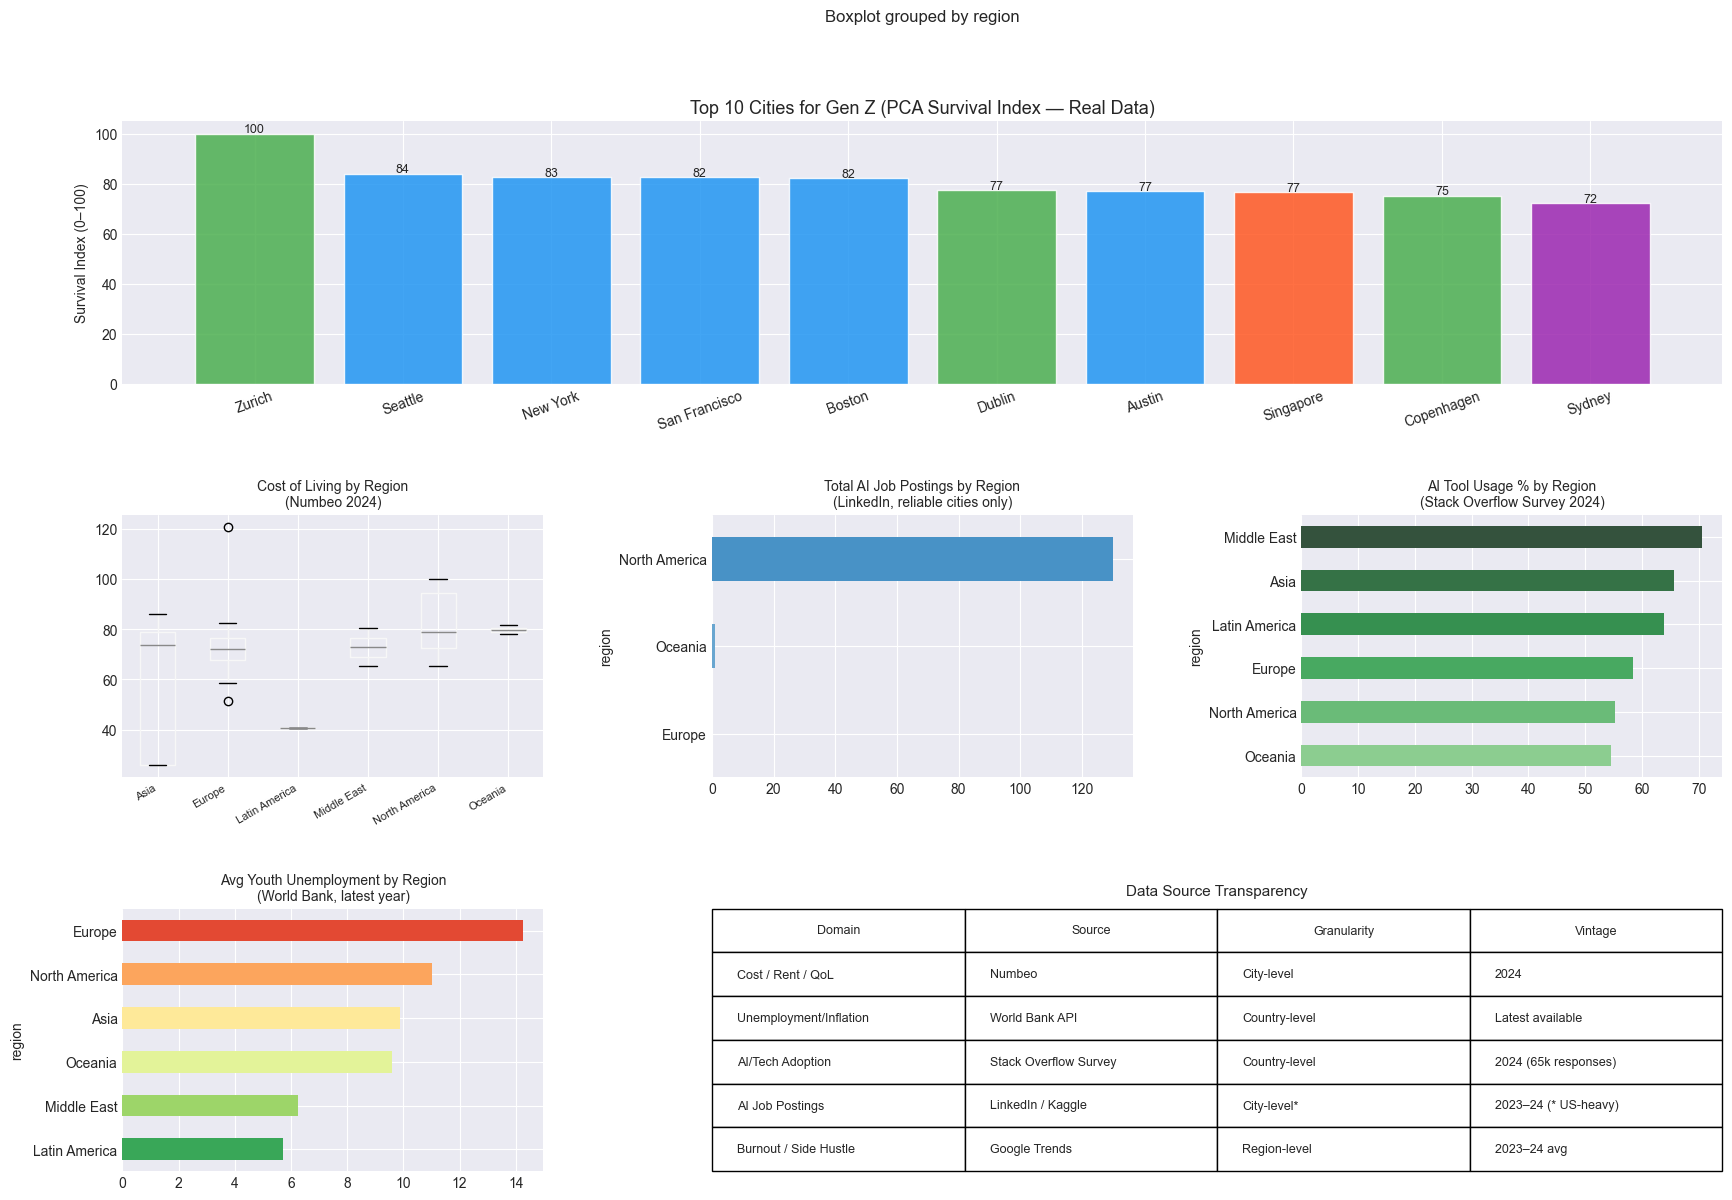

✅ Final dashboard saved


In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Gen Z Survival Dashboard 2026 — Real Data', fontsize=18, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# 1: Top 10 survival index
ax1 = fig.add_subplot(gs[0, :])
top10 = df_ranked.head(10)
colors_t10 = [REGION_COLORS.get(r,'#607D8B') for r in top10['region']]
ax1.bar(top10['city'], top10['gen_z_survival_index'], color=colors_t10, alpha=0.85, edgecolor='white')
for i, (c, v) in enumerate(zip(top10['city'], top10['gen_z_survival_index'])):
    ax1.text(i, v+0.5, f'{v:.0f}', ha='center', fontsize=9)
ax1.set_ylabel('Survival Index (0–100)')
ax1.set_title('Top 10 Cities for Gen Z (PCA Survival Index — Real Data)', fontsize=13)
ax1.tick_params(axis='x', rotation=20)

# 2: Cost of living by region
ax2 = fig.add_subplot(gs[1, 0])
df.boxplot(column='cost_of_living_index', by='region', ax=ax2)
ax2.set_title('Cost of Living by Region\n(Numbeo 2024)', fontsize=10)
ax2.set_xlabel('')
plt.sca(ax2); plt.xticks(rotation=30, ha='right', fontsize=8)

# 3: AI jobs by region (reliable only)
ax3 = fig.add_subplot(gs[1, 1])
df_reliable.groupby('region')['ai_job_postings'].sum().sort_values().plot(
    kind='barh', ax=ax3, color=sns.color_palette('Blues_d', 6))
ax3.set_title('Total AI Job Postings by Region\n(LinkedIn, reliable cities only)', fontsize=10)

# 4: AI adoption by region
ax4 = fig.add_subplot(gs[1, 2])
df.groupby('region')['ai_tool_usage_rate'].mean().sort_values().plot(
    kind='barh', ax=ax4, color=sns.color_palette('Greens_d', 6))
ax4.set_title('AI Tool Usage % by Region\n(Stack Overflow Survey 2024)', fontsize=10)

# 5: Youth unemployment
ax5 = fig.add_subplot(gs[2, 0])
df.groupby('region')['youth_unemployment_rate'].mean().sort_values().plot(
    kind='barh', ax=ax5, color=sns.color_palette('RdYlGn_r', 6))
ax5.set_title('Avg Youth Unemployment by Region\n(World Bank, latest year)', fontsize=10)

# 6: Data source table
ax6 = fig.add_subplot(gs[2, 1:])
ax6.axis('off')
src_data = [
    ['Cost / Rent / QoL',     'Numbeo',              'City-level',    '2024'],
    ['Unemployment/Inflation','World Bank API',       'Country-level', 'Latest available'],
    ['AI/Tech Adoption',      'Stack Overflow Survey','Country-level', '2024 (65k responses)'],
    ['AI Job Postings',       'LinkedIn / Kaggle',    'City-level*',   '2023–24 (* US-heavy)'],
    ['Burnout / Side Hustle', 'SO Survey 2024 proxy', 'Country-level', '2024–24 avg'],
]
tbl = ax6.table(cellText=src_data,
                colLabels=['Domain','Source','Granularity','Vintage'],
                cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
ax6.set_title('Data Source Transparency', fontsize=11, pad=10)

plt.savefig('visualizations/08_final_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Final dashboard saved')

## 5.2 Export Tableau-Ready Files

In [ ]:
os.makedirs('visualizations/tableau_data', exist_ok=True)

# Full flat file
df_tableau = df_ranked.merge(
    df[['city','population','healthcare_index','pollution_index',
        'copilot_usage_pct','job_dissatisfaction_pct','hobby_coding_pct']],
    on='city', how='left')
df_tableau.to_csv('visualizations/tableau_data/gen_z_survival_complete.csv', index=False)

# Cluster membership
df_cl[['city','country','region','cluster','pca_1','pca_2']].to_csv(
    'visualizations/tableau_data/city_clusters.csv', index=False)

print('Tableau files:')
for f in os.listdir('visualizations/tableau_data'):
    kb = os.path.getsize(f'visualizations/tableau_data/{f}') / 1024
    print(f'  {f}  ({kb:.1f} KB)')

print('\n' + '='*55)
print('PROJECT COMPLETE')
print('='*55)
print(f'Cities analysed:          {len(df)}')
print(f'Cities in survival index: {len(df_ranked)}')
print(f'Reliable LinkedIn cities: {df["data_reliable"].sum()}')
print(f'Data sources:             5 (Numbeo, WB, SO Survey, LinkedIn, Trends)')
print(f'Survival index method:    PCA PC1 (data-driven)')
print(f'Regression validation:    Leave-One-Out CV')
print(f'Correlation correction:   Bonferroni')
print(f'Cluster validation:       Silhouette Score')

Tableau files:
  ai_job_growth_timeseries.csv  (11.6 KB)
  city_clusters.csv  (2.0 KB)
  gen_z_survival_complete.csv  (4.4 KB)
  main_dashboard_data.csv  (7.7 KB)
  metrics_long_format.csv  (17.9 KB)
  score_components_long.csv  (5.5 KB)

PROJECT COMPLETE
Cities analysed:          30
Cities in survival index: 30
Reliable LinkedIn cities: 10
Data sources:             5 (Numbeo, WB, SO Survey, LinkedIn, Trends)
Survival index method:    PCA PC1 (data-driven)
Regression validation:    Leave-One-Out CV
Correlation correction:   Bonferroni
Cluster validation:       Silhouette Score
